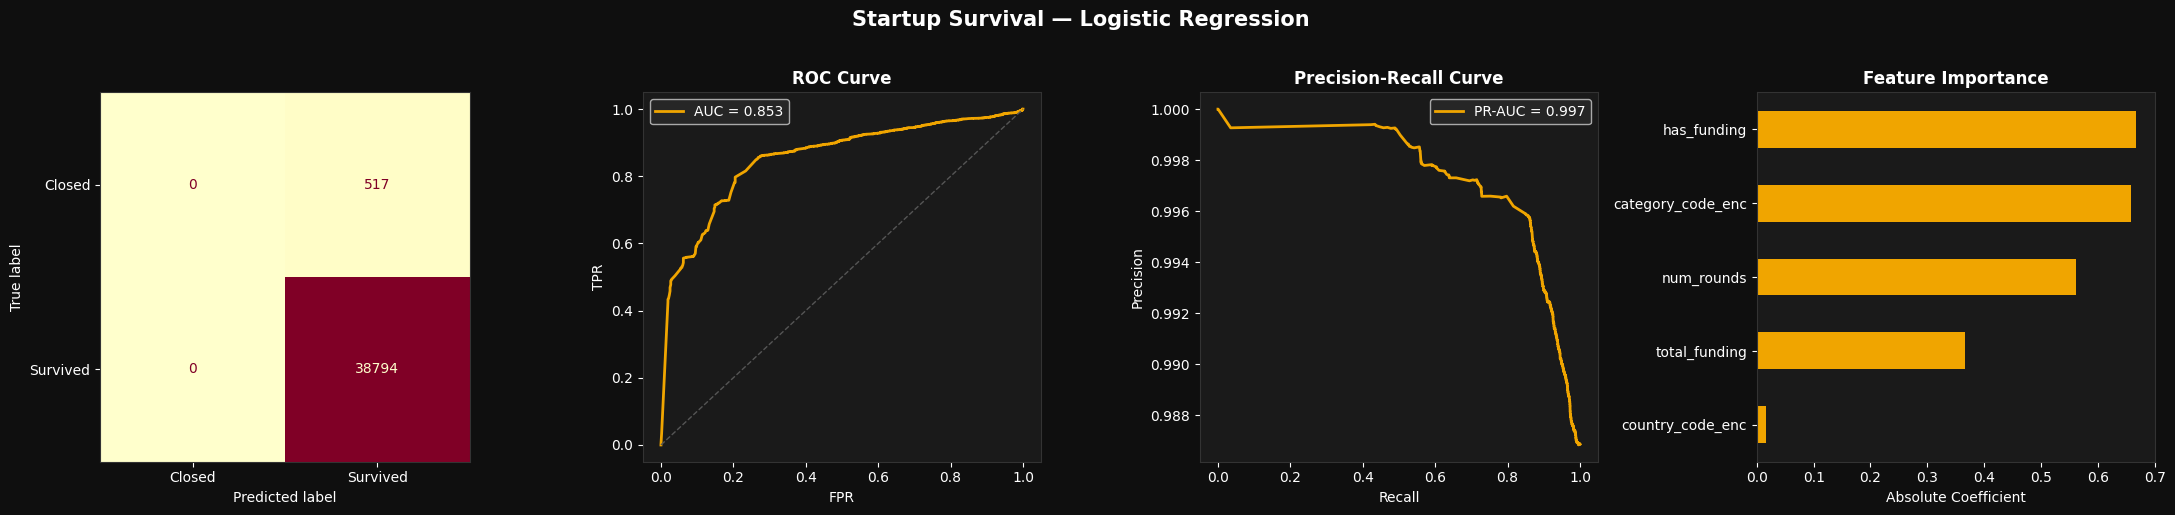

Optimal Threshold: 0.0001
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       517
           1       0.99      1.00      0.99     38794

    accuracy                           0.99     39311
   macro avg       0.49      0.50      0.50     39311
weighted avg       0.97      0.99      0.98     39311



In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import warnings

warnings.filterwarnings("ignore")

PATH = "/content"
try:
    objects        = pd.read_csv(f"{PATH}/objects.csv",        encoding="latin-1", low_memory=False)
    funding_rounds = pd.read_csv(f"{PATH}/funding_rounds.csv", encoding="latin-1", low_memory=False)
except FileNotFoundError:
    print("Error: Ensure objects.csv and funding_rounds.csv are in the /content directory.")

df = objects[objects["entity_type"] == "Company"].copy()
df = df[df["status"].isin(["operating", "acquired", "closed", "ipo"])]
df["target"] = (df["status"] != "closed").astype(int)

funding_counts = funding_rounds.groupby("object_id").agg(
    total_funding=("raised_amount_usd", "sum"),
    num_rounds=("id", "count")
).reset_index()

df = df.merge(funding_counts, left_on="id", right_on="object_id", how="left")

df["total_funding"] = df["total_funding"].fillna(0)
df["num_rounds"] = df["num_rounds"].fillna(0)
df["has_funding"] = (df["total_funding"] > 0).astype(int)

for col, n in [("country_code", 10), ("category_code", 15)]:
    top = df[col].value_counts().nlargest(n).index
    df[col] = df[col].where(df[col].isin(top), other="OTHER").fillna("UNKNOWN")
    df[col + "_enc"] = LabelEncoder().fit_transform(df[col])

FEATURES = ["total_funding", "num_rounds", "has_funding", "country_code_enc", "category_code_enc"]
X = df[FEATURES]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = ImbPipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("smote",   SMOTE(random_state=42)),
    ("clf",     LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
])

model.fit(X_train, y_train)
y_prob = model.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_thresh = thresholds[np.argmax(f1_scores)]
y_pred = (y_prob >= best_thresh).astype(int)

fig, axes = plt.subplots(1, 4, figsize=(22, 5), facecolor="#0f0f0f")
for ax in axes:
    ax.set_facecolor("#1a1a1a")

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=["Closed", "Survived"]).plot(
    ax=axes[0], colorbar=False, cmap="YlOrRd")

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color="#f0a500", lw=2, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
axes[1].plot([0, 1], [0, 1], color="#555", ls="--", lw=1)
axes[1].set(xlabel="FPR", ylabel="TPR", title="ROC Curve")
axes[1].legend(facecolor="#2a2a2a", labelcolor="white")

axes[2].plot(recall, precision, color="#f0a500", lw=2,
             label=f"PR-AUC = {average_precision_score(y_test, y_prob):.3f}")
axes[2].set(xlabel="Recall", ylabel="Precision", title="Precision-Recall Curve")
axes[2].legend(facecolor="#2a2a2a", labelcolor="white")

clf_step = model.named_steps["clf"]
coef = pd.Series(np.abs(clf_step.coef_[0]), index=FEATURES).sort_values()
coef.plot(kind="barh", ax=axes[3], color="#f0a500")
axes[3].set(title="Feature Importance", xlabel="Absolute Coefficient")

for ax in axes:
    ax.set_title(ax.get_title(), color="white", fontsize=12, fontweight="bold")
    ax.tick_params(colors="white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    for spine in ax.spines.values():
        spine.set_edgecolor("#333")

plt.suptitle("Startup Survival — Logistic Regression", color="white", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"Optimal Threshold: {best_thresh:.4f}")
print(classification_report(y_test, y_pred))